In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
plt.rc('font',family='Malgun Gothic' )
!pip install koreanize-matplotlib
from IPython.display import display
import koreanize_matplotlib
import seaborn as sns

In [2]:
origin_train=pd.read_csv("train.csv")
origin_test=pd.read_csv("test.csv")
data_train=origin_train.copy()
data_test=origin_test.copy()

In [3]:
data_train

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,NaN,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,NaN,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8035,31/10/2018,1507,19,8.4,53,NaN,2000,-0.6,0.0,0.0,0.0,Autumn,No Holiday,Yes
8036,31/10/2018,1176,20,7.6,59,0.7,2000,0.0,0.0,0.0,0.0,NaN,No Holiday,Yes
8037,31/10/2018,1069,21,7.6,59,3.0,1929,0.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
8038,31/10/2018,1088,22,6.8,58,2.2,1936,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [4]:
data_test

,Date,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/11/2018,0,5.7,62,2.3,1909,-1.0,0.0,0.0,0.0,Autumn,No Holiday,Yes
1,01/11/2018,1,5.1,65,1.6,1932,-0.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
2,01/11/2018,2,4.4,64,NaN,2000,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
3,01/11/2018,3,4.2,65,0.7,1962,-1.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
4,01/11/2018,4,3.6,70,0.8,1934,-1.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,30/11/2018,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,NaN,No Holiday,Yes
716,30/11/2018,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
717,30/11/2018,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
718,30/11/2018,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


# EDA

Rented Bike Count

In [82]:
data_train['Rented Bike Count'].describe()

count    8040.000000
mean      709.775995
std       657.320605
min         0.000000
25%       191.000000
50%       485.000000
75%      1080.500000
max      3556.000000
Name: Rented Bike Count, dtype: float64

C:\Users\user\AppData\Local\Temp\ipykernel_12884\3804792247.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=data_train, x='Hour', y='Rented Bike Count', ci=None)


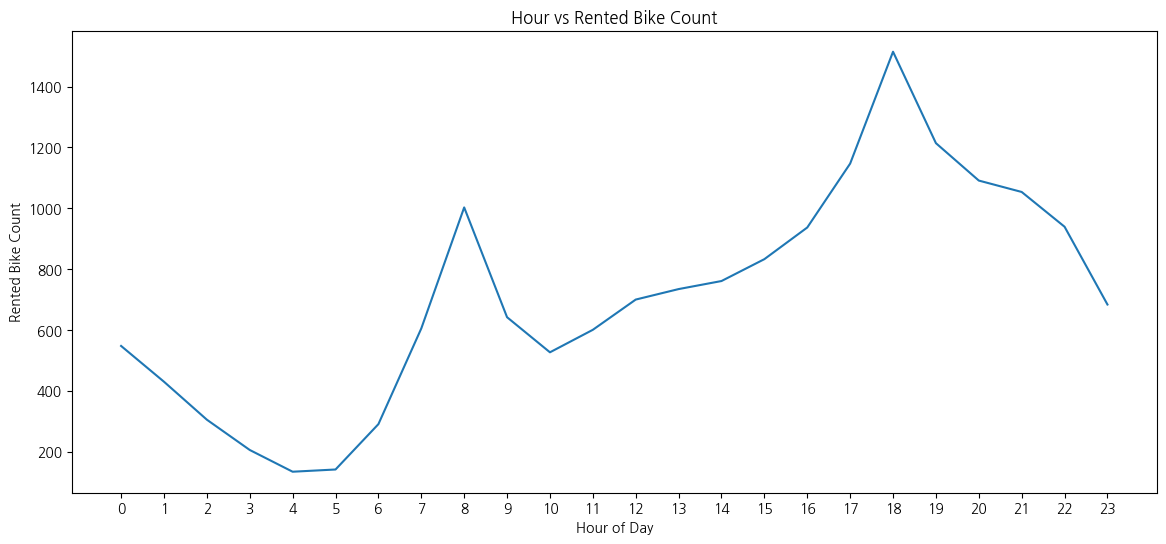

In [84]:
plt.figure(figsize=(14,6))
sns.lineplot(data=data_train, x='Hour', y='Rented Bike Count', ci=None)
plt.title('Hour vs Rented Bike Count')
plt.xlabel('Hour of Day')
plt.ylabel('Rented Bike Count')
plt.xticks(range(0,24))
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_12884\1483958208.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=data_train, x='Hour', y='Rented Bike Count', hue='Seasons', ci=None)


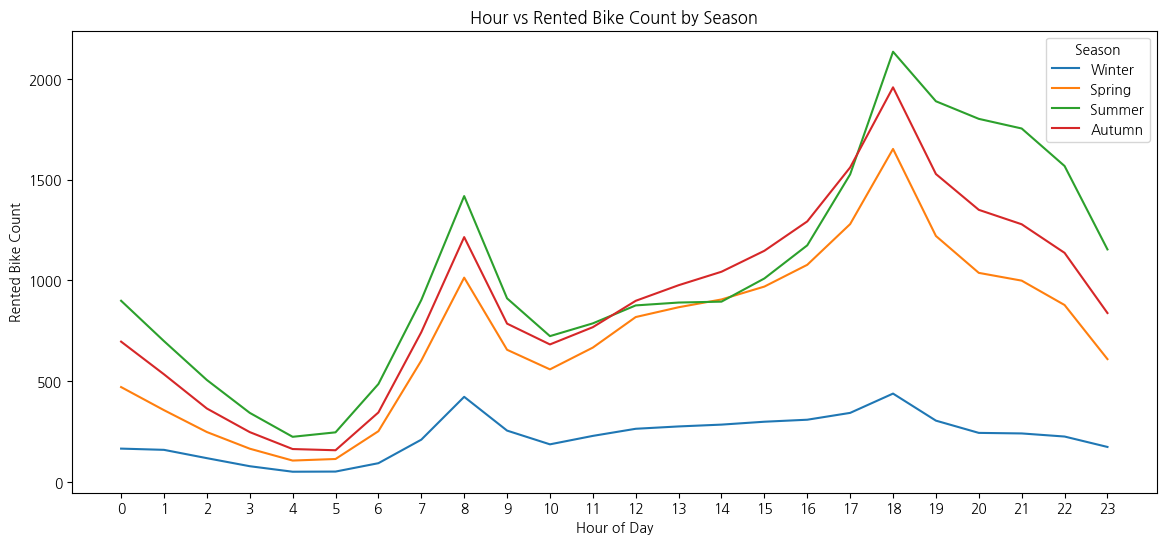

In [85]:
# 시즌별 비교
plt.figure(figsize=(14,6))
sns.lineplot(data=data_train, x='Hour', y='Rented Bike Count', hue='Seasons', ci=None)
plt.title('Hour vs Rented Bike Count by Season')
plt.xlabel('Hour of Day')
plt.ylabel('Rented Bike Count')
plt.xticks(range(0,24))
plt.legend(title='Season')
plt.show()

1. 시간대별
- 07 ~ 09시 , 17 ~ 19시가 가장 많음을 확인
- 출퇴근 시간대에 해당
2. 시즌별
- 겨울에는 추위, 눈 등의 날씨 요인 때문에 자전거 이용이 줄어드는 경향을 보임 

## Temperature

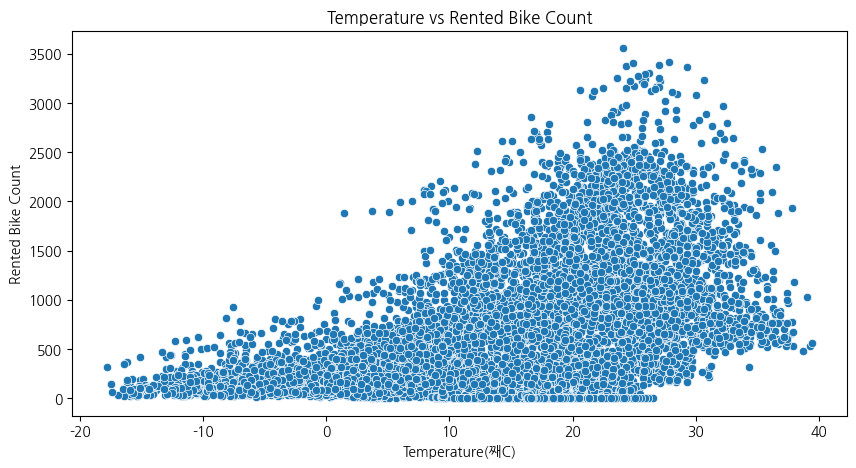

In [89]:
# 2. Temperature vs Rented Bike Count
plt.figure(figsize=(10,5))
sns.scatterplot(data=data_train, x='Temperature(째C)', y='Rented Bike Count')
plt.title('Temperature vs Rented Bike Count')
plt.show()

- 너무 낮거나 높은 온도는 야외 활동 감소 → 이용량 감소, 적정 기온에서는 증가
- 10도에서 30도 사이 몰려있는걸 볼 수 있음

## Humidity

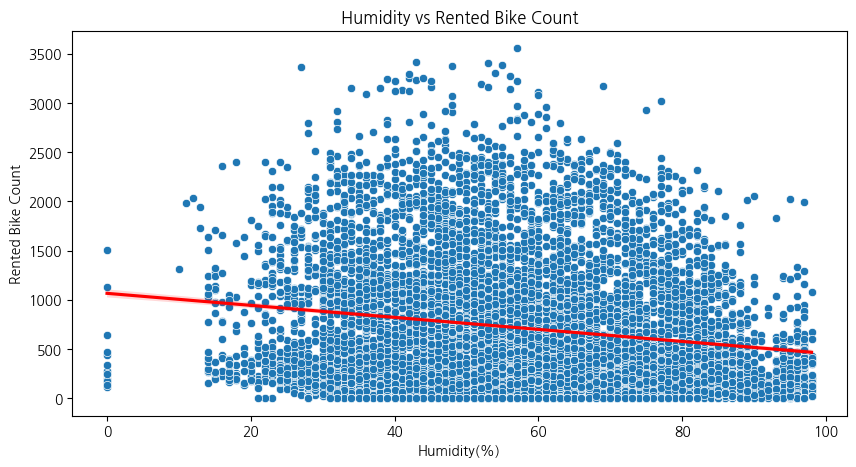

In [108]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=data_train, x='Humidity(%)', y='Rented Bike Count')
sns.regplot(data=data_train, x='Humidity(%)', y='Rented Bike Count', scatter=False, color='red')
plt.title('Humidity vs Rented Bike Count')
plt.show()

습도가 높으면 불쾌감 → 야외 자전거 이용 감소
- 습도가 높아질수록 rented bike count는 감소
- 회귀선으로도 기울기가 음수임을 확인할 수 있음

다른 변수들을 확인해보았을 때, 이상치 없음 확인할 수 있음

In [100]:
data_train["Visibility (10m)"].describe()

count    8040.000000
mean     1459.170896
std       603.716284
min        27.000000
25%       977.000000
50%      1741.000000
75%      2000.000000
max      2000.000000
Name: Visibility (10m), dtype: float64

In [98]:
data_train["Dew point temperature(째C)"].describe()

count    8040.000000
mean        4.522239
std        13.393517
min       -30.600000
25%        -4.600000
50%         6.400000
75%        15.600000
max        27.200000
Name: Dew point temperature(째C), dtype: float64

In [102]:
data_train["Solar Radiation (MJ/m2)"].describe()

count    8040.000000
mean        0.587072
std         0.886186
min         0.000000
25%         0.000000
50%         0.020000
75%         0.960000
max         3.520000
Name: Solar Radiation (MJ/m2), dtype: float64

In [103]:
data_train["Rainfall(mm)"].describe()

count    8040.000000
mean        0.152164
std         1.127026
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        35.000000
Name: Rainfall(mm), dtype: float64

In [104]:
data_train["Snowfall (cm)"].describe()

count    8040.000000
mean        0.066493
std         0.378182
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         5.100000
Name: Snowfall (cm), dtype: float64

# 기상청 데이터를 이용해 결측치 채우기
 * https://data.kma.go.kr/data/grnd/selectAsosRltmList.do?pgmNo=36
 * https://www.weather.go.kr/w/resources/pdf/kma_data_portal_guide.pdf
 * 일단 이 데이터로 결측치를 채우기 적절한지 판단하기 위해 2가지 정도 생각해볼 수 있다.
   1. 결측치를 제외한 나머지 값들이 모두 동일한가?
   2. 결측치 부분에 적절한 값이 들어가 있는가?
   

In [5]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8040 entries, 0 to 8039
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8040 non-null   object 
 1   Rented Bike Count          8040 non-null   int64  
 2   Hour                       8040 non-null   int64  
 3   Temperature(째C)            7240 non-null   float64
 4   Humidity(%)                8040 non-null   int64  
 5   Wind speed (m/s)           7238 non-null   float64
 6   Visibility (10m)           8040 non-null   int64  
 7   Dew point temperature(째C)  8040 non-null   float64
 8   Solar Radiation (MJ/m2)    8040 non-null   float64
 9   Rainfall(mm)               8040 non-null   float64
 10  Snowfall (cm)              8040 non-null   float64
 11  Seasons                    7238 non-null   object 
 12  Holiday                    8040 non-null   object 
 13  Functioning Day            8040 non-null   objec

- 결측치 확인 

In [6]:
data_train.isnull().sum()

Date                           0
Rented Bike Count              0
Hour                           0
Temperature(째C)              800
Humidity(%)                    0
Wind speed (m/s)             802
Visibility (10m)               0
Dew point temperature(째C)      0
Solar Radiation (MJ/m2)        0
Rainfall(mm)                   0
Snowfall (cm)                  0
Seasons                      802
Holiday                        0
Functioning Day                0
dtype: int64

결측치가 0으로 표기되어있을 수 있으므로 확인 
- Humidity, Wind speed, Visibility 는 0이 거의 불가능

In [7]:
zero_count = (data_train == 0).sum()
zero_ratio = (data_train == 0).mean() * 100

pd.DataFrame({
    'zero_count': zero_count,
    'zero_ratio(%)': zero_ratio
}).sort_values('zero_count', ascending=False)

,zero_count,zero_ratio(%)
Snowfall (cm),7648,95.124378
Rainfall(mm),7529,93.644279
Solar Radiation (MJ/m2),3890,48.383085
Hour,335,4.166667
Rented Bike Count,223,2.773632
Wind speed (m/s),53,0.659204
Dew point temperature(째C),45,0.559701
Temperature(째C),17,0.211443
Humidity(%),17,0.211443
Date,0,0.000000


# **기온 결측치 채우기**
![설명](이슬점공식.png)

- Dewpoint = 이슬점
- T = 기온
- RH = humidity

In [8]:
import numpy as np

def dewpoint_to_temp(Td, RH):
    """
    Td : 이슬점 (°C)
    RH : 상대습도 (%)
    return : 기온 (°C)
    """
    gamma = (17.625 * Td) / (243.04 + Td) - np.log(RH / 100)
    T = (243.04 * gamma) / (17.625 - gamma)
    return T

**temp 결측치 채우기**

In [9]:
mask = (
    data_train['Temperature(째C)'].isna() &
    data_train['Humidity(%)'].notna() &
    data_train['Dew point temperature(째C)'].notna() &
    (data_train['Humidity(%)'] > 0)
)

data_train.loc[mask, 'Temperature(째C)'] = dewpoint_to_temp(
    data_train.loc[mask, 'Dew point temperature(째C)'],
    data_train.loc[mask, 'Humidity(%)']
)

In [10]:
print("Temperature 결측치 개수:",
      data_train['Temperature(째C)'].isna().sum())

Temperature 결측치 개수: 1


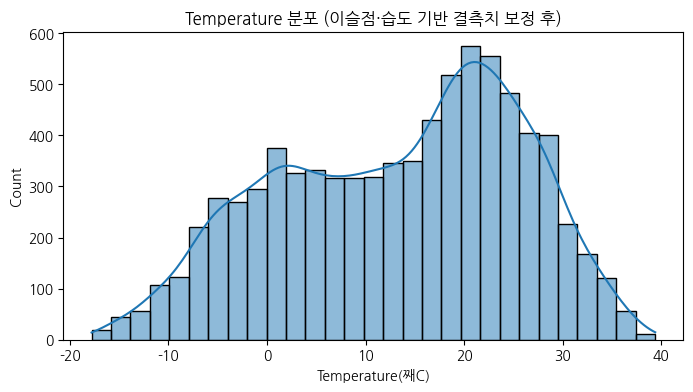

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(data_train['Temperature(째C)'], kde=True)
plt.title("Temperature 분포 (이슬점·습도 기반 결측치 보정 후)")
plt.show()

In [12]:
mask = ( data_train['Temperature(째C)'].isna() &
    (data_train['Humidity(%)'] == 0))
data_train.loc[mask]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
4131,22/05/2018,406,3,NaN,0,0.7,1420,10.4,0.0,0.0,0.0,NaN,Holiday,Yes


In [13]:
#2018.05.22 데이터 찾아서 넣기 
#기온 15.5, 습도 72
mask = data_train['Temperature(째C)'].isna()

data_train.loc[mask, 'Temperature(째C)'] = 15.5
data_train.loc[mask, 'Humidity(%)'] = 72

In [14]:
print("Temperature 결측치 개수:",
      data_train['Temperature(째C)'].isna().sum()) 
#결측치 개수 0인거 확인 

Temperature 결측치 개수: 0


**windspeed 결측치 채우기**

In [15]:
#기상청데이터
obs_asos_wind=pd.read_csv("OBS_ASOS.csv", encoding='cp949')
data_asos=obs_asos_wind.copy()

In [16]:
data_asos

,지점,지점명,일시,풍속(m/s),습도(%)
0,108,서울,2017-12-01 01:00,0.8,38
1,108,서울,2017-12-01 02:00,1.0,39
2,108,서울,2017-12-01 03:00,0.9,40
3,108,서울,2017-12-01 04:00,2.3,36
4,108,서울,2017-12-01 05:00,1.5,37
...,...,...,...,...,...
9475,108,서울,2018-12-30 20:00,0.8,34
9476,108,서울,2018-12-30 21:00,1.2,33
9477,108,서울,2018-12-30 22:00,1.1,38
9478,108,서울,2018-12-30 23:00,1.6,40


In [17]:
data_asos.columns

Index(['지점', '지점명', '일시', '풍속(m/s)', '습도(%)'], dtype='object')

In [18]:
# ASOS 데이터 불러오기
obs_asos_wind = pd.read_csv("OBS_ASOS.csv", encoding='cp949')
data_asos = obs_asos_wind.copy()

# 일시 → datetime
data_asos['일시'] = pd.to_datetime(data_asos['일시'])

# Date / Hour 분리 (train 형식)
data_asos['Date'] = data_asos['일시'].dt.strftime('%d/%m/%Y')
data_asos['Hour'] = data_asos['일시'].dt.hour

# 컬럼명 train 기준으로 통일
data_asos = data_asos.rename(columns={
    '풍속(m/s)': 'Wind speed (m/s)',
    '습도(%)': 'Humidity(%)'
})

# 필요한 컬럼만 사용
data_asos = data_asos[['Date', 'Hour', 'Wind speed (m/s)', 'Humidity(%)']]


In [19]:
# Date 타입 통일
data_train['Date'] = pd.to_datetime(
    data_train['Date'],
    format='%d/%m/%Y'
).dt.strftime('%d/%m/%Y')

# Hour 정수형 보장
data_train['Hour'] = data_train['Hour'].astype(int)

In [20]:
data_train = data_train.merge(
    data_asos,
    on=['Date', 'Hour'],
    how='left',
    suffixes=('', '_asos')
)

In [21]:
mask = data_train['Wind speed (m/s)'].isna()

data_train.loc[mask, 'Wind speed (m/s)'] = \
    data_train.loc[mask, 'Wind speed (m/s)_asos']

In [22]:
data_train = data_train.drop(
    columns=['Wind speed (m/s)_asos', 'Humidity(%)_asos'],
    errors='ignore'
)

In [23]:
data_train['Wind speed (m/s)'].isna().sum()

np.int64(2)

- 기상청데이터로도 채우지 못한 데이터는 전 인덱스와 후 인덱스 평균으로 넣기

In [24]:
data_train[data_train['Wind speed (m/s)'].isna()]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
118,05/12/2017,393,22,-2.8,49,NaN,2000,-12.0,0.00,0.0,0.0,Winter,No Holiday,Yes
129,06/12/2017,440,9,-3.3,70,NaN,1324,-7.9,0.25,0.0,0.2,Winter,No Holiday,Yes


In [25]:
data_train.loc[[117, 118, 119, 128, 129, 130]]

,Date,Rented Bike Count,Hour,Temperature(째C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(째C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
117,05/12/2017,415,21,-3.7,47,0.0,2000,-13.3,0.00,0.0,0.0,Winter,No Holiday,Yes
118,05/12/2017,393,22,-2.8,49,NaN,2000,-12.0,0.00,0.0,0.0,Winter,No Holiday,Yes
119,05/12/2017,244,23,-2.5,59,0.0,1210,-9.4,0.00,0.0,0.0,Winter,No Holiday,Yes
128,06/12/2017,802,8,-4.2,78,0.0,1518,-7.4,0.01,0.0,0.2,Winter,No Holiday,Yes
129,06/12/2017,440,9,-3.3,70,NaN,1324,-7.9,0.25,0.0,0.2,Winter,No Holiday,Yes
130,06/12/2017,307,10,-0.9,64,0.0,1224,-6.8,0.63,0.0,0.2,Winter,No Holiday,Yes


In [26]:
#앞뒤가 0이므로 0으로 넣겠음 
data_train.loc[[118, 129], 'Wind speed (m/s)'] = 0
data_train['Wind speed (m/s)'].isna().sum()

np.int64(0)

**Seasons 결측치 채우기**
- 계절기준으로 채우기

| 월       | Season |
| ------- | ------ |
| 3,4,5   | Spring |
| 6,7,8   | Summer |
| 9,10,11 | Autumn |
| 12,1,2  | Winter |


In [27]:
data_train['Date'] = pd.to_datetime(data_train['Date'], dayfirst=True)

In [28]:
#month 추출 
data_train['Month'] = data_train['Date'].dt.month

In [29]:
def month_to_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

In [30]:
mask = data_train['Seasons'].isna()
data_train.loc[mask, 'Seasons'] = data_train.loc[mask, 'Month'].apply(month_to_season)

In [31]:
data_train['Seasons'].isna().sum()

np.int64(0)

In [32]:
data_train.drop(columns='Month', inplace=True)
#다 채웠으니 컬럼 제거

- test 데이터도 해야해 ....요

In [33]:
data_test.isnull().sum()

Date                          0
Hour                          0
Temperature(째C)              76
Humidity(%)                   0
Wind speed (m/s)             74
Visibility (10m)              0
Dew point temperature(째C)     0
Solar Radiation (MJ/m2)       0
Rainfall(mm)                  0
Snowfall (cm)                 0
Seasons                      74
Holiday                       0
Functioning Day               0
dtype: int64

- Temperature가 N
- Humidity, Dew point는 존재
- Humidity > 0 인 행만 골라서
- 이슬점 + 상대습도 → 기온 역산
- test 데이터 기준으로 결측치 채움

In [36]:
#temp
import numpy as np

def dewpoint_to_temp(Td, RH):
    """
    Td : 이슬점 (°C)
    RH : 상대습도 (%)
    return : 기온 (°C)
    """
    gamma = (17.625 * Td) / (243.04 + Td) - np.log(RH / 100)
    T = (243.04 * gamma) / (17.625 - gamma)
    return T

In [37]:
mask = (
    data_test['Temperature(째C)'].isna() &
    data_test['Humidity(%)'].notna() &
    data_test['Dew point temperature(째C)'].notna() &
    (data_test['Humidity(%)'] > 0)
)

data_test.loc[mask, 'Temperature(째C)'] = dewpoint_to_temp(
    data_test.loc[mask, 'Dew point temperature(째C)'],
    data_test.loc[mask, 'Humidity(%)']
)

print(
    "Temperature 결측치 개수:",
    data_test['Temperature(째C)'].isna().sum()
)


Temperature 결측치 개수: 0


- windspeed

In [39]:
# Date 타입 통일 (test)
data_test['Date'] = pd.to_datetime(
    data_test['Date'],
    format='%d/%m/%Y'
).dt.strftime('%d/%m/%Y')

# Hour 정수형 
data_test['Hour'] = data_test['Hour'].astype(int)

# ASOS 데이터와 merge
data_test = data_test.merge(
    data_asos,
    on=['Date', 'Hour'],
    how='left',
    suffixes=('', '_asos')
)

# Wind speed 결측치 → ASOS 값으로 채우기
mask = data_test['Wind speed (m/s)'].isna()
data_test.loc[mask, 'Wind speed (m/s)'] = \
    data_test.loc[mask, 'Wind speed (m/s)_asos']

# 필요없는 보조 컬럼 제거
data_test = data_test.drop(
    columns=['Wind speed (m/s)_asos', 'Humidity(%)_asos'],
    errors='ignore'
)

# 결과 확인
data_test['Wind speed (m/s)'].isna().sum()

np.int64(0)

- Seasons

In [40]:
# Date를 datetime으로 변환
data_test['Date'] = pd.to_datetime(data_test['Date'], dayfirst=True)

# Month 추출
data_test['Month'] = data_test['Date'].dt.month

# 월 → 시즌 매핑 함수
def month_to_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

# Seasons 결측치만 채우기
mask = data_test['Seasons'].isna()
data_test.loc[mask, 'Seasons'] = data_test.loc[mask, 'Month'].apply(month_to_season)

# 확인
data_test['Seasons'].isna().sum()


np.int64(0)

train / test 처리 기준을 반드시 일관되게 시행 
- 모델은 ‘전처리된 결과’를 학습
-> train / test 전처리가 다르면 같은 현상을 다른 의미로 해석
  => "분포 불일치"라고 함
- 일관성 = 성능 + 신뢰 + 재현성

**모델링진행**

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [49]:
#타깃변수 
y = data_train['Rented Bike Count']

In [59]:
#입력변수
X = data_train.drop(columns=['Rented Bike Count', 'Date'])
X_test = data_test.drop(columns=['Date'])

In [60]:
#범주형 / 수치형 구분 
cat_cols = ['Seasons', 'Holiday', 'Functioning Day']
num_cols = [col for col in X.columns if col not in cat_cols]

In [61]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

1. 선형회귀
- 입력 변수와 대여량 간의 선형 관계를 가정
- 숫자형 + 범주형(one-hot)만 입력 가능

In [63]:
#학습
lr_model = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

lr_model.fit(X, y)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
#test
test_pred_lr = lr_model.predict(X_test)

2. 랜덤포레스트 회귀
- 여러 개의 결정트리를 앙상블한 모델
- 비선형 관계와 변수 간 상호작용을 잘 반영할 수 있다는 장점

In [69]:
rf_model = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X, y)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [70]:
test_pred_rf = rf_model.predict(X_test)

In [71]:
#train 성능 비교 
train_pred_lr = lr_model.predict(X)
train_pred_rf = rf_model.predict(X)

print("Linear Regression R2:", r2_score(y, train_pred_lr))
print("Random Forest R2:", r2_score(y, train_pred_rf))

Linear Regression R2: 0.5575470541415682
Random Forest R2: 0.9832506816021873


두 모델 결정계수 (R^2) 값 
- Linear Regression: 0.558
- Random Forest Regression: 0.983

- Linear Regression: 단순하고 해석 쉬움, 직선 관계 기반
- Random Forest: 예측력 높음, 복잡한 패턴도 학습 가능, 해석은 어려움
- R² 차이가 큰 이유: 데이터가 선형이 아니라 비선형 패턴을 포함하고 있음

- radom forest가 0.98로 너무 높아서 과적합 가능성 있음 
- 교차검증 (데이터 셋을 여러 조각으로 나눠, 각 조각을 한 번씩 검증용으로 사용하며 학습) 시행

- X 데이터에 문자열(Seasons: 'Winter', 'Spring', …)이 포함되어 있어서 랜덤포레스트가 숫자로 변환할 수 없
- RandomForestRegressor나 LinearRegression 모두 숫자형 데이터만 입력
- 해결 방법 : 원-핫 인코딩 (One-Hot Encoding)

In [78]:
# X에 남아있는 object 타입 컬럼 확인
print(X.select_dtypes(include='object').columns)

Index(['Seasons', 'Holiday', 'Functioning Day'], dtype='object')


In [80]:
import pandas as pd

# 범주형 컬럼 리스트
cat_cols = ['Seasons', 'Holiday', 'Functioning Day']

# train 데이터 원-핫
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# test 데이터 원-핫
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# train 기준으로 test 컬럼 맞춤
X_test_encoded = X_test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

# 확인
print(X_encoded.head())
print(X_test_encoded.head())

   Hour  Temperature(째C)  Humidity(%)  Wind speed (m/s)  Visibility (10m)  \
0     0             -5.2           37               2.2              2000   
1     1             -5.5           38               0.8              2000   
2     2             -6.0           39               1.0              2000   
3     3             -6.2           40               0.9              2000   
4     4             -6.0           36               2.3              2000   

   Dew point temperature(째C)  Solar Radiation (MJ/m2)  Rainfall(mm)  \
0                      -17.6                      0.0           0.0   
1                      -17.6                      0.0           0.0   
2                      -17.7                      0.0           0.0   
3                      -17.6                      0.0           0.0   
4                      -18.6                      0.0           0.0   

   Snowfall (cm)  Seasons_Spring  Seasons_Summer  Seasons_Winter  \
0            0.0           False          

- 교차검증 적용

In [81]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(random_state=42, n_estimators=100)

# 교차검증
scores = cross_val_score(rf, X_encoded, y, cv=5, scoring='r2')
print("교차검증 R²:", scores)
print("평균 R²:", scores.mean())

교차검증 R²: [0.46601152 0.43446126 0.7692751  0.723591   0.64133958]
평균 R²: 0.6069356929565946


1. fold별 R² 편차가 크고 평균이 0.607 → train 성능과 큰 차이
- 과적합이 존재한다고 판단 가능

2. 모델은 학습 데이터에는 거의 완벽히 맞췄지만, 새로운 데이터(test)에는 설명력이 크게 떨어질 수 있음

개선 방안 
1. 모델 단순화 / 하이퍼파라미터 튜닝
- max_depth, min_samples_leaf, n_estimators 조정
- 모델 복잡도를 낮춰 과적합 완화
2. 다른 모델 비교
- Gradient Boosting, XGBoost, LightGBM 등
- 단일 결정트리 기반이 아닌 앙상블 모델 시도